# JEPA from Scratch
NGL this may be way over my expertise, but I thought I would explore a contrarian view to the magical AI everyone seems to be talking about. Lecun's JEPA model is interesting in that instead of being a next word predictor, it tries to learn the true physics of the system its placed in. It does this by a process called "self-supervised" learning. 

To break it down, we start with the basics. We use a linear model for demonstration, but we can swap this for a more powerful model.

### 1. Forward Pass
Let us first define:

$$X \in \mathbb{R}^{N \times D_{in}}, \quad Y \in \mathbb{R}^{N \times D_{in}}$$

Where X is the feature inputs and Y is the response vector. First, we have to encode the contexts, using learnable weights:

$$ Z_{x} = XW_{x}$$

We also compute the target embeddings:
$$ Z_{y} = YW_{y}$$

Note that W_y is not learned, but is fixed for every forward pass + backprop loop.

Finally, we use a last set of learnable weights to form a prediction for Z_y in the future.

$$ \hat{Z_{y}} = Z_{x}W_{p} = XW_{x}W_{p}$$

And that concludes each forward pass.


### 2. Loss Functions
The interesting thing about JEPA is that it makes use of two loss functions. Due to the simplicity of the model itself, it requires guardrails to ensure it doesn't collapse to the mean. For the first loss function, we can use MSE:

$$\mathcal{L}_{pred} = \frac{1}{2N}\sum^{N}_{i = 1}\|\hat{Z_{y, i}}-Z_{y, i}\|^{2}\\[1em]
=\frac{1}{2N}Tr((\hat{Z_y}-Z_y)(\hat{Z_y}-Z_y)^{T})$$

Now the second one is a bit more interesting. Models making use of MSE can tend to collapse to the mean. Hence, we introduce another loss function to regulate variance. First, we get the variance formula as follows:

$$\sigma_j^2 = \frac{1}{N-1} \sum_{i=1}^{N} (Z_{x, ij} - \hat{Z}_{x, j})^2$$

Where j is a latent variable.

From here, we can define the loss function as:

$$\mathcal{L}_{var} = \frac{1}{D_{embed}}\sum^{D_{embed}}_{j=0}max(0, 1.0 - \sigma_j)$$

Adding these up, we get a total loss of:

$$\mathcal{L}_{total} = \mathcal{L}_{pred} +\gamma\mathcal{L}_{var}$$

### Partial Derivatives
We can see that theres two vectors to optimize, W_p and W_x. Through chain rule we get the following:

$$\frac{\partial L_{total}}{\partial W_{p}} = \frac{\partial L_{pred}}{\partial \hat{Z_{y}}} \cdot \frac{\partial Z_{y}}{\partial W_{p}}$$

Evaluating these we get:
$$ \frac{\partial L_{pred}}{\partial \hat{Z_{y}}} = \frac{1}{N}(Z_{x, ij} - \hat{Z}_{x, j})\\[1em]
\frac{\partial Z_{y}}{\partial W_{p}} = Z_{x}^{T}$$

Putting these together we get:
$$\frac{\partial L_{total}}{\partial W_{p}} = \frac{1}{N} \cdot Z_{x}^{T} (Z_{x, ij} - \hat{Z}_{x, j})$$

Now we move on to W_x, the context encoder:

$$\frac{\partial \mathcal{L}_{total}}{\partial W_x} = \frac{\partial \mathcal{L}_{pred}}{\partial W_x} + \gamma \frac{\partial \mathcal{L}_{var}}{\partial W_x}$$

For the first half, we can decompose it using chain rule:

$$\frac{\partial \mathcal{L}_{pred}}{\partial W_x} = \frac{\partial \mathcal{L}_{pred}}{\partial \tilde{Z}_y} \cdot \frac{\partial \tilde{Z}_y}{\partial Z_x} \cdot \frac{\partial Z_x}{\partial W_x}$$

The first one was already calculated in the the prediction segment. The rest are as follows:

$$\frac{\partial \tilde{Z}_y}{\partial Z_x} = W_p\\[1em]
\frac{\partial Z_x}{\partial W_x} = X$$

Sticking this teogether we get:

$$\frac{\partial \mathcal{L}_{pred}}{\partial W_x} = X^T \cdot \left[ \frac{1}{N}(\tilde{Z}_y - Z_y) \right] \cdot W_p^T$$

The second half, we let S be an N x D_embed gradient mask matrix where $S_{ij} = -\frac{\gamma}{D_{embed} \cdot (N-1)} \cdot \frac{Z_{x,ij} - \bar{Z}_{x,j}}{\sigma_j}$ if $\sigma_j < 1.0$, else $0$. 

$$\frac{\partial \mathcal{L}_{var}}{\partial W_x} = X^T S$$

Combining these we get:
$$\frac{\partial \mathcal{L}_{total}}{\partial W_x} = X^T \left( \frac{1}{N}(\tilde{Z}_y - Z_y)W_p^T + \gamma S \right)$$


### Gradient Descent

This part is fairly straightforward:
$$W_p = W_p - lr \cdot \frac{\partial \mathcal{L}_{total}}{\partial W_p}\\[1em]W_x = W_x - lr \cdot \frac{\partial \mathcal{L}_{total}}{\partial W_x}$$

### Updating W_y

Now this is the part that makes JEPA interesting. We update W_y as follows:
$$W_y = \tau W_y + (1 - \tau) W_x$$

And that's all! Let's get to the code. 





In [10]:
import numpy as np
import matplotlib.pyplot as plt

def compute_losses_and_mask(Z_x, Z_y, pred_Z_y, gamma):
    N, D_embed = Z_x.shape
    
    # =========================================================================
    # 1. Prediction Loss (L_pred)
    # Math: 1/(2N) * sum(||pred_Z_y - Z_y||^2)
    # =========================================================================
    error = pred_Z_y - Z_y
    loss_pred = 0.5 * np.sum(error ** 2) / N
    
    # =========================================================================
    # 2. Variance Loss (L_var) & S Mask Matrix
    # Math: 1/D_embed * sum(max(0, 1.0 - sigma_j))
    # =========================================================================
    # Step A: Compute means and standard deviations along the batch axis (axis=0)
    # z_means shape: (D_embed,) | z_stds shape: (D_embed,)
    z_means = np.mean(Z_x, axis=0)
    z_stds = np.std(Z_x, axis=0, ddof=1) # ddof=1 forces 1/(N-1) sample variance
    
    # Step B: Add a tiny epsilon to prevent division by zero if variance collapses
    eps = 1e-4
    z_stds_safe = z_stds + eps
    
    # Step C: Calculate the hinge loss component
    loss_var = np.mean(np.maximum(0.0, 1.0 - z_stds))
    
    # Total Loss
    loss_total = loss_pred + gamma * loss_var
    
    # =========================================================================
    # 3. Generating the S Mask Matrix for Backprop
    # Math: If sigma_j < 1.0, S_ij = -1/(D_embed * (N-1)) * (Z_x_ij - mean_j) / sigma_j
    #       Else, S_ij = 0
    # =========================================================================
    # Broadcast the deviations across rows: shape (N, D_embed)
    deviations = Z_x - z_means  
    
    # Compute the raw baseline gradient matrix
    S_raw = -1.0 / (D_embed * (N - 1)) * (deviations / z_stds_safe)
    
    # Create a boolean condition mask where std < 1.0 (broadcasts across rows)
    # shape: (N, D_embed)
    condition = z_stds < 1.0
    
    # If the condition is met, use S_raw; otherwise, set to 0.0
    S = np.where(condition, S_raw, 0.0)
    
    return loss_total, error, S


In [23]:
def forward(X, W_x, W_p, Y, W_y):
    Z_x = np.dot(X, W_x)
    Z_y = np.dot(Y, W_y)
    pred_Z_y = np.dot(Z_x, W_p)

    return Z_x, Z_y, pred_Z_y

def backward(X, Z_x, W_p, error, S, gamma, W_x):
    N = X.shape[0]

    dW_p = np.dot(Z_x.T, error) / N

    grad_from_pred = np.dot(error, W_p.T) / N
    total_latent_grad = grad_from_pred + gamma * S

    dW_x = np.dot(X.T, total_latent_grad)

    return dW_p, dW_x

def grad_desc(W_p, dW_p, W_x, dW_x, lr, W_y, tau):
    W_p = W_p - lr * dW_p
    W_x = W_x - lr * dW_x
    W_y = tau * W_y + (1.0 - tau) * W_x

    return W_p, W_x, W_y


Training JEPA to identify hidden structural physics...
Epoch 000 | Total Loss: 8.2427 | Latent Std: 0.4582
Epoch 050 | Total Loss: 0.0693 | Latent Std: 1.7188
Epoch 100 | Total Loss: 0.0146 | Latent Std: 2.0993
Epoch 150 | Total Loss: 0.0068 | Latent Std: 2.3514
Epoch 200 | Total Loss: 0.0056 | Latent Std: 2.5288
Epoch 250 | Total Loss: 0.0056 | Latent Std: 2.6593
Epoch 300 | Total Loss: 0.0058 | Latent Std: 2.7555
Epoch 350 | Total Loss: 0.0060 | Latent Std: 2.8262


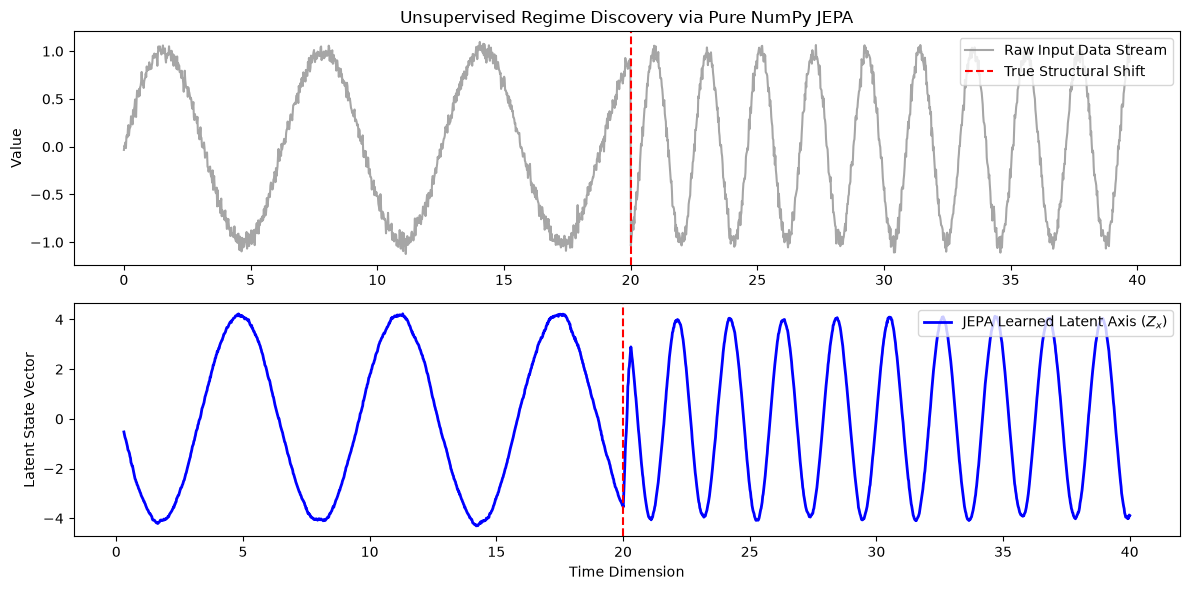

In [101]:
t = np.linspace(0, 40, 2000)

# Regime 0: Smooth Sine | Regime 1: Fast, High-frequency Cosine
data = np.where(t < 20, np.sin(t), np.cos(3 * t)) 
# Add subtle real-world market ambient noise
data += np.random.normal(0, 0.05, data.shape)

window_size = 15
X_data, Y_data = [], []
for i in range(len(data) - window_size):
    X_data.append(data[i : i + window_size])
    Y_data.append(data[i + 1 : i + window_size + 1])

X_data = np.array(X_data) # Shape: (N, D_in)
Y_data = np.array(Y_data) # Shape: (N, D_in)

# =========================================================================
# 3. Hyperparameters & Weight Initializations
# =========================================================================
N, D_in = X_data.shape
D_embed = 1  # Force down to a 1D structural signal to map our regime switch!
epochs = 400
lr = 0.01
gamma = 15.0 # Strong muscle to push against representation collapse
tau = 0.99   # Slow, smooth target encoder track

W_x = np.random.normal(0, 0.1, (D_in, D_embed))
W_p = np.random.normal(0, 0.1, (D_embed, D_embed))
W_y = W_x.copy() # Target starts aligned with Context

# =========================================================================
# 4. Unsupervised Training Optimization Loop
# =========================================================================
print("Training JEPA to identify hidden structural physics...")
for epoch in range(epochs):
    Z_x, Z_y, pred_Z_y = forward(X_data, W_x, W_p, Y_data, W_y)
    loss, error, S = compute_losses_and_mask(Z_x, Z_y, pred_Z_y, gamma)
    dW_p, dW_x = backward(X_data, Z_x, W_p, error, S, gamma, W_x)
    W_p, W_x, W_y = grad_desc(W_p, dW_p, W_x, dW_x, lr, W_y, tau)
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss:.4f} | Latent Std: {np.std(Z_x):.4f}")

# Extract final discovered latent states
final_Z_x, _, _ = forward(X_data, W_x, W_p, Y_data, W_y)

# =========================================================================
# 5. Graphing the Verification Plot
# =========================================================================
# =========================================================================
# 5. Graphing the Verification Plot (Fixed Look-Ahead Alignment)
# =========================================================================
plt.figure(figsize=(12, 6))

# Plot 1: The Raw Input Stream Data (Indexed to the start/current element of the window)
plt.subplot(2, 1, 1)
plt.plot(t[:len(X_data)], X_data[:, 0], color='gray', alpha=0.7, label='Raw Input Data Stream')
plt.axvline(x=20, color='red', linestyle='--', label='True Structural Shift')
plt.title("Unsupervised Regime Discovery via Pure NumPy JEPA")
plt.ylabel("Value")
plt.legend(loc='upper right')

# Plot 2: JEPA's Hidden Latent Coordinate (Aligned to the actual end of the lookback window)
plt.subplot(2, 1, 2)
# FIX: Shift the time vector by window_size to map where the encoder is actually looking
t_latent = t[window_size : len(X_data) + window_size] 

plt.plot(t_latent, final_Z_x[:, 0], color='blue', linewidth=2, label="JEPA Learned Latent Axis ($Z_x$)")
plt.axvline(x=20, color='red', linestyle='--')
plt.ylabel("Latent State Vector")
plt.xlabel("Time Dimension")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


Training JEPA to identify hidden structural physics...
Epoch 000 | Total Loss: 8.9489 | Latent Std: 0.4091
Epoch 050 | Total Loss: 0.0684 | Latent Std: 1.6061
Epoch 100 | Total Loss: 0.0182 | Latent Std: 1.9743
Epoch 150 | Total Loss: 0.0088 | Latent Std: 2.2353
Epoch 200 | Total Loss: 0.0077 | Latent Std: 2.4175
Epoch 250 | Total Loss: 0.0078 | Latent Std: 2.5505
Epoch 300 | Total Loss: 0.0081 | Latent Std: 2.6471
Epoch 350 | Total Loss: 0.0083 | Latent Std: 2.7155


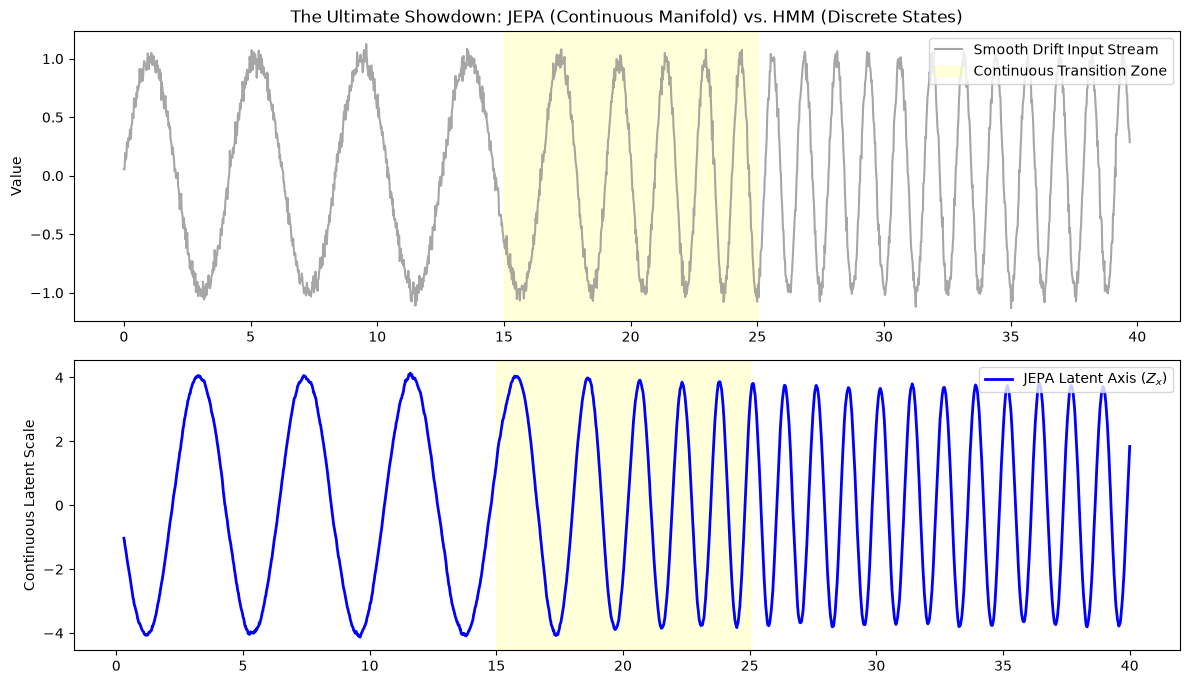

In [138]:

np.random.seed(42)
t = np.linspace(0, 40, 2000)

frequency_profile = np.where(t < 15, 1.5, np.where(t > 25, 5.0, 1.5 + (5.0 - 1.5) * (t - 15) / 10))

phase = np.cumsum(frequency_profile) * (t[1] - t[0])
data = np.sin(phase) + np.random.normal(0, 0.05, t.shape)

window_size = 15
X_data, Y_data = [], []
for i in range(len(data) - window_size):
    X_data.append(data[i : i + window_size])
    Y_data.append(data[i + 1 : i + window_size + 1])

X_data = np.array(X_data)
Y_data = np.array(Y_data)
N, D_in = X_data.shape
D_embed = 1  
epochs = 400
lr = 0.01
gamma = 15.0 
tau = 0.99   

W_x = np.random.normal(0, 0.1, (D_in, D_embed))
W_p = np.random.normal(0, 0.1, (D_embed, D_embed))
W_y = W_x.copy() 
print("Training JEPA to identify hidden structural physics...")
for epoch in range(epochs):
    Z_x, Z_y, pred_Z_y = forward(X_data, W_x, W_p, Y_data, W_y)
    loss, error, S = compute_losses_and_mask(Z_x, Z_y, pred_Z_y, gamma)
    dW_p, dW_x = backward(X_data, Z_x, W_p, error, S, gamma, W_x)
    W_p, W_x, W_y = grad_desc(W_p, dW_p, W_x, dW_x, lr, W_y, tau)
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss:.4f} | Latent Std: {np.std(Z_x):.4f}")

# Extract final discovered latent states
final_Z_x, _, _ = forward(X_data, W_x, W_p, Y_data, W_y)


plt.figure(figsize=(12, 10))


plt.subplot(3, 1, 1)
plt.plot(t[:len(X_data)], X_data[:, 0], color='gray', alpha=0.7, label='Smooth Drift Input Stream')
plt.axvspan(15, 25, color='yellow', alpha=0.15, label='Continuous Transition Zone')
plt.title("The Ultimate Showdown: JEPA (Continuous Manifold) vs. HMM (Discrete States)")
plt.ylabel("Value")
plt.legend(loc='upper right')

plt.subplot(3, 1, 2)
t_latent = t[window_size : len(X_data) + window_size] 
plt.plot(t_latent, final_Z_x[:, 0], color='blue', linewidth=2, label="JEPA Latent Axis ($Z_x$)")
plt.axvspan(15, 25, color='yellow', alpha=0.15)
plt.ylabel("Continuous Latent Scale")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


Interestingly, we can see that the JEPA architecture gave us a model that is inversed vertically. This is a side effect of the variance loss function, making it sign invariant. JEPA provides us with a framework, and the nice thing is that we can substutite the linear model we used with other models such as neural networks, LSTMs, and so on!